In [19]:
import pandas as pd
import pickle   
from geoai.utils_geo.raster_ops import RasterOperations
from geoai.utils_ml.model_ops import ModelOperations
from geoai.utils_ds.visualize_ops import VisualizeOperations

model_ops = ModelOperations()
vis_ops = VisualizeOperations()
raster_ops = RasterOperations()

In [2]:
X_train = pd.read_csv("csv_files/X_train.csv")
X_test = pd.read_csv("csv_files/X_test.csv")
y_train = pd.read_csv("csv_files/y_train.csv")
y_test = pd.read_csv("csv_files/y_test.csv")
X_train.head(1)

,BLUE,GREEN,RED,NIR,SWIR
0,373.5,519.5,389.0,3034.0,1991.0


In [5]:
# Subset the data to only include the bands used in fitting the model
rgbnir_train = X_train[["BLUE", "GREEN", "RED", "NIR"]]
rgbnir_test = X_test[["BLUE", "GREEN", "RED", "NIR"]]

In [6]:
# Load the simple model
with open("trained_models/simple.pkl", "rb") as file:
    simple_model = pickle.load(file)

In [7]:
simple_model

LogisticRegression(max_iter=100000, random_state=42)

In [8]:
# make predictions for train and test data
simple_preds_train = simple_model.predict(rgbnir_train)
simple_preds_test = simple_model.predict(rgbnir_test)

In [9]:
# compute for the train and test data the accuracy of the simple model
print("Simple Model Accuracy")
print(f"Train Accuracy: {model_ops.calculate_classification_accuracy(y_train, simple_preds_train)}")
print(f"Test Accuracy: {model_ops.calculate_classification_accuracy(y_test, simple_preds_test)}")


Simple Model Accuracy
Train Accuracy: (0.8630490956072352, 0.8637207792550923, 0.8630490956072352, 0.8633322989381884)
Test Accuracy: (0.8760330578512396, 0.8755063979536191, 0.8760330578512396, 0.8756870576139825)


# Types of Accuracy

## Accuracy 

<b><i>Defintion</b></i>: ratio of correctly predicted instances (both true positives and true negatives) to the total instances.

<b><i>Use Case</b></i>:
Best for balanced datasets where the number of positive and negative samples are roughly equal.
Not informative for imbalanced datasets as it can be misleading (e.g., high accuracy in a dataset where the majority class dominates).


## Precision 

<b><i>Defintion</b></i>: ratio of correctly predicted positive observations to the total predicted positives.

<b><i>Use Case</b></i>:
Useful in situations where the cost of false positives is high. Important in cases like spam detection, where you want to minimize the number of legitimate emails marked as spam.


## Recall 

<b><i>Defintion</b></i>: ratio of correctly predicted positive observations to all actual positives.

<b><i>Use Case</b></i>:
Useful in situations where the cost of false negatives is high. Important in cases like disease screening, where you want to minimize the number of actual cases that are missed.


## F1-Score 

<b><i>Defintion</b></i>: The F1-score is the harmonic mean of precision and recall, providing a single metric that balances both concerns.

<b><i>Use Case</b></i>:
Useful when you need a balance between precision and recall.
Best used when the class distribution is imbalanced.

| Metric    | Best Used When                                | Caveat                               |
|-----------|-----------------------------------|-----------------------------------------------|
| Accuracy  | Dataset is balanced                          | Misleading for imbalanced datasets   |
| Precision | Cost of false positives is high               | May ignore false negatives           |
| Recall    | Cost of false negatives is high               | May ignore false positives           |
| F1-Score  | Need a balance between precision and recall | May be lower than precision and recall |


# Confusion matrix

- True Positive (TP): The number of instances that were correctly classified.
- False Positive (FP): The number of instances that were incorrectly classified as a given class.
- False Negative (FN): The number of instances that were incorrectly classified as another class.
- True Negative (TN): The number of instances that were correctly not classified as a given class.

<img src="figures/confmat.png" alt="Alt text" width="500" height="300">

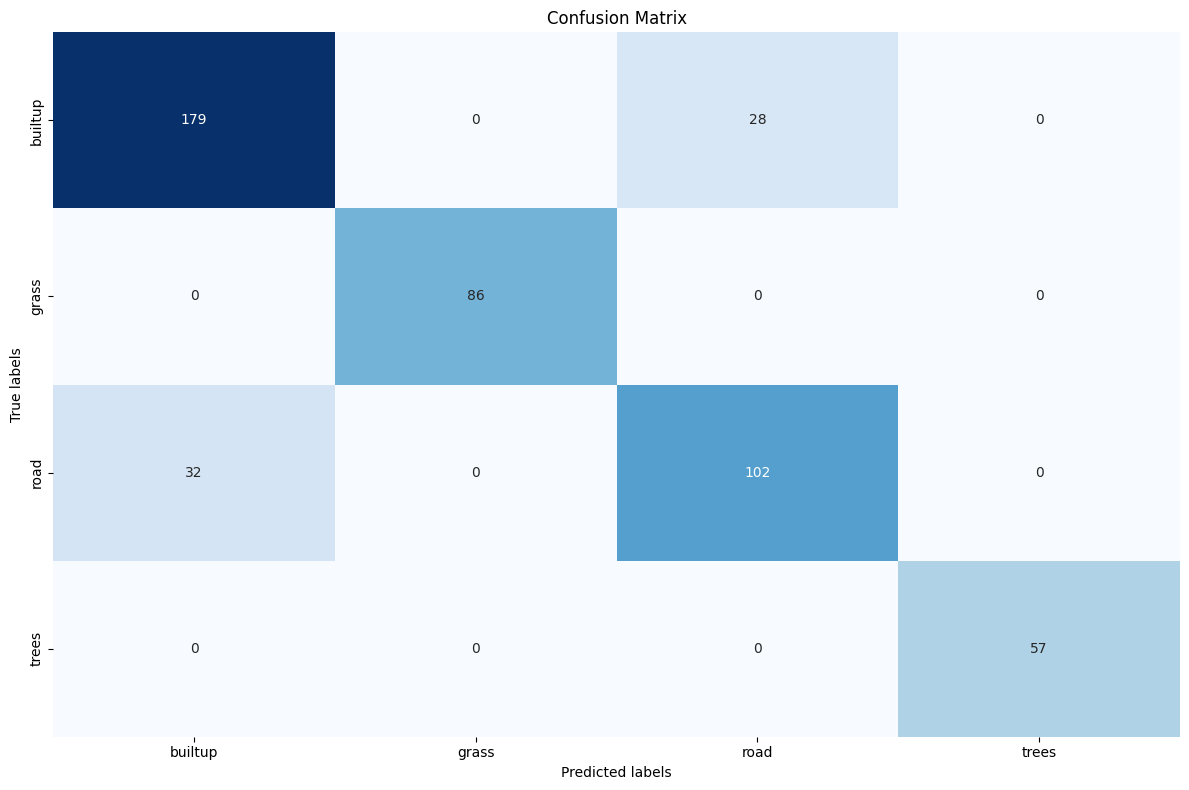

In [13]:
label_mapping = {0: "builtup", 1: "grass", 2: "road", 3: "trees"}
class_names_str = [label_mapping[label] for label in simple_model.classes_]
vis_ops.plot_confusion_matrix(y_test, simple_preds_test, class_names_str)

# True Positives (TP): 

The diagonal elements (from top left to bottom right) represent the true positives for each class.

- builtup: 179 instances correctly predicted as builtup.
- grass: 86 instances correctly predicted as grass.
- road: 102 instances correctly predicted as road.
- trees: 57 instances correctly predicted as trees.


# False Positives (FP):

These are the values in the same column but not on the diagonal. They represent instances that were incorrectly predicted as that class.

- builtup: 32 roads incorrectly predicted as builtup.
- grass: 0 instances incorrectly predicted as grass.
- road: 28 builtup incorrectly predicted as road.
- trees: 0 instances incorrectly predicted as trees.

#False Negatives (FN):

These are the values in the same row but not on the diagonal. They represent instances that were incorrectly not predicted as that class.

- builtup: 28 builtup incorrectly predicted as road.
- grass: 0 instances incorrectly predicted as not grass.
- road: 32 roads incorrectly predicted as builtup.
- trees: 0 instances incorrectly predicted as not trees.

# True Negatives (TN):

These are all the values that are not on the row or column of the current class. They represent instances that were correctly not predicted as that class.

In [15]:
# Load the our best model
with open("trained_models/stacked.pkl", "rb") as file:
    stacked = pickle.load(file)

In [16]:
stacked

StackingClassifier(estimators=[('cat',
                                Pipeline(steps=[('preprocessor',
                                                 ColumnTransformer(transformers=[('num',
                                                                                  Pipeline(steps=[('poly',
                                                                                                   PolynomialFeatures()),
                                                                                                  ('select',
                                                                                                   SelectKBest(k=24))]),
                                                                                  ['BLUE',
                                                                                   'GREEN',
                                                                                   'RED',
                                                                                   'NIR',
                                                                                   'SWIR',
                                                                                   'NDVI',
                                                                                   'NDBI',
                                                                                   'REI']),
                                                                                 ('onehot',
                                                                                  OneHotEncoder(dtype=<class 'int'>,
                                                                                                sparse_output=False),
                                                                                  ['NDVI_bin']),
                                                                                 ('ordinal',
                                                                                  OrdinalEncoder(cat...
                                                                                  OneHotEncoder(dtype=<class 'int'>,
                                                                                                sparse_output=False),
                                                                                  ['NDVI_bin']),
                                                                                 ('ordinal',
                                                                                  OrdinalEncoder(categories=[['low_veg',
                                                                                                              'medium_veg',
                                                                                                              'high_veg']],
                                                                                                 dtype=<class 'int'>),
                                                                                  ['NDVI_dis'])])),
                                                ('scale', MinMaxScaler()),
                                                ('dim_reduce',
                                                 LinearDiscriminantAnalysis(n_components=3)),
                                                ('classifier',
                                                 SVC(class_weight={0: 1, 1: 1,
                                                                   2: 10,
                                                                   3: 1}))]))],
                   final_estimator=LogisticRegression(), n_jobs=-1)

In [20]:
# compute for the addition features needed
X_train = raster_ops.compute_ndvi_using_df(X_train, "NIR", "RED")
X_train = raster_ops.compute_ndbi(X_train, "NIR", "SWIR")
X_train = raster_ops.compute_rei(X_train, "NIR", "BLUE")
X_test = raster_ops.compute_ndvi_using_df(X_test, "NIR", "RED")
X_test = raster_ops.compute_ndbi(X_test, "NIR", "SWIR")
X_test = raster_ops.compute_rei(X_test, "NIR", "BLUE")


# create binary and discrete NDVI
X_train = raster_ops.create_ndvi_bin(X_train, "NDVI")
X_train = raster_ops.create_ndvi_discrete(X_train, "NDVI")
X_test = raster_ops.create_ndvi_bin(X_test, "NDVI")
X_test = raster_ops.create_ndvi_discrete(X_test, "NDVI")

In [21]:
# make predictions for train and test data
stacked_preds_train = stacked.predict(X_train)
stacked_preds_test = stacked.predict(X_test)

In [22]:
# compute for the train and test data the accuracy of the stacked model
print("Stacked Model Accuracy")
print(f"Train Accuracy: {model_ops.calculate_classification_accuracy(y_train, stacked_preds_train)}")
print(f"Test Accuracy: {model_ops.calculate_classification_accuracy(y_test, stacked_preds_test)}")


Stacked Model Accuracy
Train Accuracy: (0.9731266149870801, 0.9737568126411766, 0.9731266149870801, 0.9732248703478262)
Test Accuracy: (0.9628099173553719, 0.96350244057164, 0.9628099173553719, 0.962943651551228)


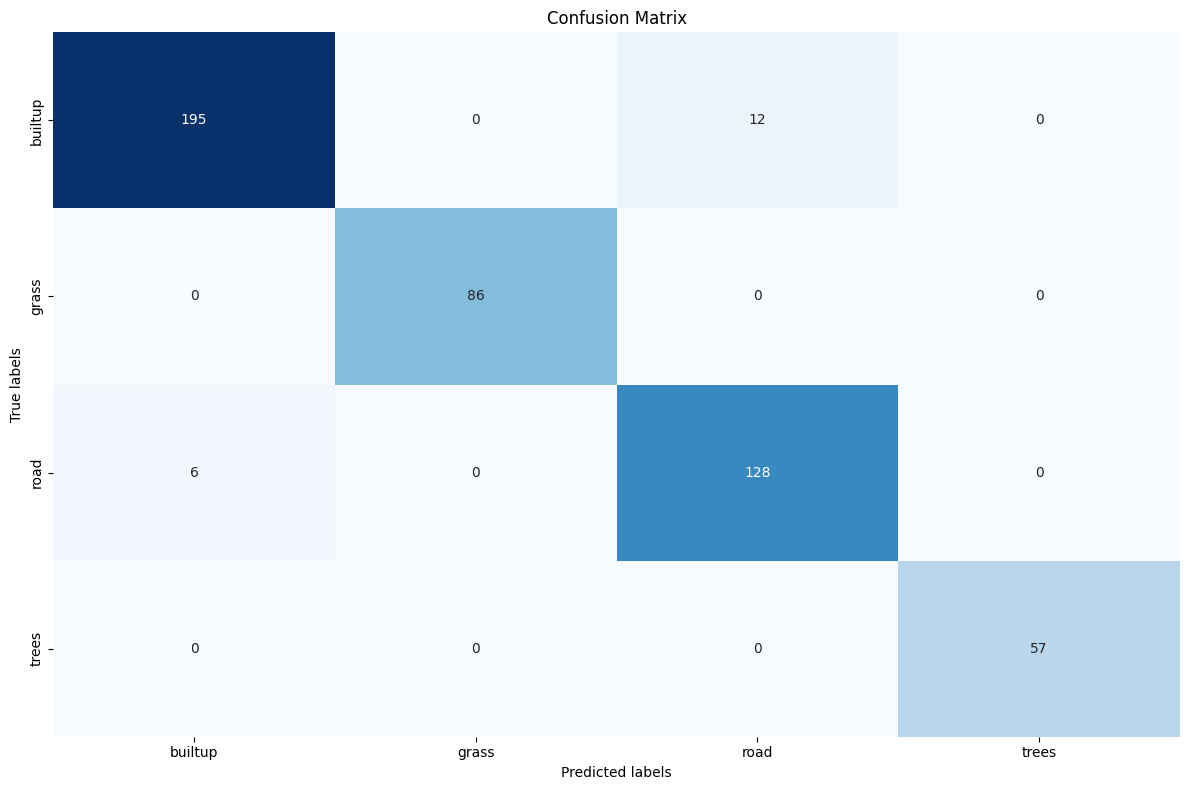

In [23]:
label_mapping = {0: "builtup", 1: "grass", 2: "road", 3: "trees"}
class_names_str = [label_mapping[label] for label in stacked.classes_]
vis_ops.plot_confusion_matrix(y_test, stacked_preds_test, class_names_str)